In [1]:
import time
import os
import torch
import torch.nn.functional as F
from torch.distributions import Categorical, kl
from d2l.torch import Animator

from net import Net
from aco import ACO
from utils import gen_pyg_data, load_val_dataset

torch.manual_seed(1234)

lr = 3e-4
EPS = 1e-10
T = 5
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

In [2]:
def train_instance(model, optimizer, pyg_data, distances, n_ants, use_mcts=True, mcts_simulations=50):
    model.train()
    heu_vec = model(pyg_data)
    heu_mat = model.reshape(pyg_data, heu_vec) + EPS
    
    aco = ACO(
        n_ants=n_ants,
        heuristic=heu_mat,
        distances=distances,
        device=device,
        use_mcts=use_mcts,
        mcts_simulations=mcts_simulations
        )
    
    costs, log_probs = aco.sample()

    baseline = costs.mean()
    reinforce_loss = torch.sum((costs - baseline) * log_probs.sum(dim=0)) / aco.n_ants
    optimizer.zero_grad()
    reinforce_loss.backward()
    optimizer.step()
    return reinforce_loss.item()

def infer_instance(model, pyg_data, distances, n_ants, use_mcts=True, mcts_simulations=50):
    model.eval()
    heu_vec = model(pyg_data)
    heu_mat = model.reshape(pyg_data, heu_vec) + EPS
    aco = ACO(
        n_ants=n_ants,
        heuristic=heu_mat,
        distances=distances,
        device=device,
        use_mcts=use_mcts,
        mcts_simulations=mcts_simulations
        )
    costs, log_probs = aco.sample()
    aco.run(n_iterations=T)
    baseline = costs.mean()
    best_sample_cost = torch.min(costs)
    best_aco_cost = aco.lowest_cost
    return baseline.item(), best_sample_cost.item(), best_aco_cost.item()

def train(n_node, k_sparse, n_ants, steps_per_epoch, epochs, use_mcts=True, mcts_simulations=50, dual_eval=False):
    net = Net().to(device)
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)
    val_list = load_val_dataset(n_node, k_sparse, device)

    if dual_eval:
        animator = Animator(
            xlabel='epoch',
            xlim=[0, epochs],
            legend=[
                'Base Avg. sample obj.',
                'Base Best sample obj.',
                'Base Best ACO obj.',
                'MCTS Avg. sample obj.',
                'MCTS Best sample obj.',
                'MCTS Best ACO obj.',
            ],
        )
        base0, mcts0 = validation_dual(n_ants, -1, net, val_list, animator, mcts_simulations=mcts_simulations)
        val_results = {'base': [base0], 'mcts': [mcts0]}
    else:
        animator = Animator(
            xlabel='epoch',
            xlim=[0, epochs],
            legend=["Avg. sample obj.", "Best sample obj.", "Best ACO obj."],
        )
        avg_bl, avg_best, avg_aco_best = validation(n_ants, -1, net, val_list, animator, use_mcts, mcts_simulations)
        val_results = [(avg_bl, avg_best, avg_aco_best)]

    sum_time = 0
    for epoch in range(0, epochs):
        start = time.time()
        train_epoch(n_node, n_ants, k_sparse, epoch, steps_per_epoch, net, optimizer, use_mcts, mcts_simulations)
        sum_time += time.time() - start

        if dual_eval:
            base_e, mcts_e = validation_dual(n_ants, epoch, net, val_list, animator, mcts_simulations=mcts_simulations)
            val_results['base'].append(base_e)
            val_results['mcts'].append(mcts_e)
        else:
            avg_bl, avg_sample_best, avg_aco_best = validation(n_ants, epoch, net, val_list, animator, use_mcts, mcts_simulations)
            val_results.append((avg_bl, avg_sample_best, avg_aco_best))

    print('total training duration:', sum_time)
    if dual_eval:
        for epoch in range(-1, epochs):
            print(f'epoch {epoch} base:', val_results['base'][epoch + 1])
            print(f'epoch {epoch} mcts:', val_results['mcts'][epoch + 1])
    else:
        for epoch in range(-1, epochs):
            print(f'epoch {epoch}:', val_results[epoch + 1])

    # 保存模型
    os.makedirs('../pretrained_1/tsp_MCTS', exist_ok=True)
    torch.save(net.state_dict(), f'../pretrained_1/tsp_MCTS/tsp{n_node}.pt')

    return net

In [3]:
def train_epoch(n_node,
                n_ants, 
                k_sparse, 
                epoch, 
                steps_per_epoch, 
                net, 
                optimizer,
                use_mcts=True,
                mcts_simulations=50
                ):
    for _ in range(steps_per_epoch):
        instance = torch.rand(size=(n_node, 2), device=device)
        data, distances = gen_pyg_data(instance, k_sparse=k_sparse)
        train_instance(net, optimizer, data, distances, n_ants, use_mcts, mcts_simulations)

In [4]:
@torch.no_grad()
def validation(n_ants, epoch, net, val_dataset, animator=None, use_mcts=True, mcts_simulations=5):
    sum_bl, sum_sample_best, sum_aco_best = 0, 0, 0

    for data, distances in val_dataset:
        bl, sample_best, aco_best = infer_instance(net, data, distances, n_ants, use_mcts, mcts_simulations)
        sum_bl += bl
        sum_sample_best += sample_best
        sum_aco_best += aco_best

    n_val = len(val_dataset)
    avg_bl = sum_bl / n_val
    avg_sample_best = sum_sample_best / n_val
    avg_aco_best = sum_aco_best / n_val

    if animator is not None:
        animator.add(epoch + 1, (avg_bl, avg_sample_best, avg_aco_best))

    return avg_bl, avg_sample_best, avg_aco_best


@torch.no_grad()
def validation_dual(
    n_ants,
    epoch,
    net,
    val_dataset,
    animator=None,
    mcts_simulations=5,
):
    """同时评估 use_mcts=False 与 use_mcts=True，便于定位收益来源。"""
    avg_bl_base, avg_best_base, avg_aco_best_base = validation(
        n_ants,
        epoch,
        net,
        val_dataset,
        animator=None,
        use_mcts=False,
        mcts_simulations=mcts_simulations,
    )

    avg_bl_mcts, avg_best_mcts, avg_aco_best_mcts = validation(
        n_ants,
        epoch,
        net,
        val_dataset,
        animator=None,
        use_mcts=True,
        mcts_simulations=mcts_simulations,
    )

    if animator is not None:
        # 画两条曲线：base 与 mcts（各自三指标）
        animator.add(
            epoch + 1,
            (
                avg_bl_base,
                avg_best_base,
                avg_aco_best_base,
                avg_bl_mcts,
                avg_best_mcts,
                avg_aco_best_mcts,
            ),
        )

    return (avg_bl_base, avg_best_base, avg_aco_best_base), (avg_bl_mcts, avg_best_mcts, avg_aco_best_mcts)

In [5]:
def distill_instance(
    model,
    optimizer,
    pyg_data,
    distances,
    n_ants_teacher=1,
    mcts_simulations=20,
    teacher_every=2,
    soft_teacher=True,
    visit_eps=1e-3,
):
    """MCTS→Net 蒸馏。

    soft_teacher=True：用根节点子节点 visit 构造老师分布，最小化 KL(teacher || student)。
    soft_teacher=False：沿用单步 argmax visit 的 hard label（-log pi(a)）。

    - 仅在每 teacher_every 步计入 teacher loss，其余步 on-policy 采样以降频
    - n_ants_teacher 默认 1 用于提速
    """
    model.train()

    heu_vec = model(pyg_data)
    heu_mat = model.reshape(pyg_data, heu_vec) + EPS

    aco = ACO(
        n_ants=n_ants_teacher,
        heuristic=heu_mat,
        distances=distances,
        device=device,
        use_mcts=True,
        mcts_simulations=mcts_simulations,
    )

    if soft_teacher:
        aco.mcts.set_cache(None)
        aco.mcts.set_soft_cache({})
    else:
        aco.mcts.set_soft_cache(None)
        aco.mcts.set_cache({})

    start = torch.randint(low=0, high=aco.problem_size, size=(1,), device=device)
    mask = torch.ones(size=(1, aco.problem_size), device=device)
    mask[0, start[0]] = 0

    path = [start[0].item()]
    prev = start

    losses = []
    for step in range(aco.problem_size - 1):
        aco.mcts.pheromone = aco.pheromone
        aco.mcts.heuristic = aco.heuristic
        aco.mcts.alpha = aco.alpha
        aco.mcts.beta = aco.beta

        pheromone_i = aco.pheromone[prev[0]]
        heuristic_i = aco.heuristic[prev[0]]
        s_logits = (pheromone_i ** aco.alpha) * (heuristic_i ** aco.beta)
        s_logits = s_logits.masked_fill(mask[0] < 0.5, -1e9)
        log_student = F.log_softmax(s_logits, dim=-1)

        use_teacher = (teacher_every is not None) and (teacher_every > 0) and (step % teacher_every == 0)
        if use_teacher:
            if soft_teacher:
                p_teacher = aco.mcts.root_visit_policy_tensor(
                    path, device=device, dtype=heu_mat.dtype, visit_eps=visit_eps
                ).detach()
                # KL(p_teacher || pi_student) = sum_a p_t (log p_t - log pi_s)
                losses.append(F.kl_div(log_student, p_teacher, reduction="sum"))
                action = int(torch.argmax(p_teacher).item())
            else:
                dist = Categorical(logits=s_logits)
                action = aco.mcts.search(path)
                losses.append(-dist.log_prob(torch.tensor(action, device=device)))
                prev = torch.tensor([action], device=device)
                mask[0, action] = 0
                path.append(action)
                continue
        else:
            dist = Categorical(logits=s_logits)
            action = dist.sample().item()

        prev = torch.tensor([action], device=device)
        mask[0, action] = 0
        path.append(action)

    if not losses:
        return 0.0

    loss = torch.stack(losses).mean()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return float(loss.item())


def distill_finetune(
    n_node,
    k_sparse,
    net,
    optimizer,
    steps_per_epoch,
    epochs,
    n_ants_teacher=1,
    mcts_simulations=20,
    teacher_every=2,
    val_mcts_simulations=5,
    soft_teacher=True,
    visit_eps=1e-3,
    save_dir='../pretrained_1/tsp_MCTS_fineturning',
    save_name=None,
):
    """末期蒸馏微调：默认可选 KL(visit 分布) 或 hard CE。

    会在结束时保存微调后的权重，便于后续测试复现。
    """
    val_list = load_val_dataset(n_node, k_sparse, device)
    animator = Animator(
        xlabel="epoch",
        xlim=[0, epochs],
        legend=[
            "Base Avg. sample obj.",
            "Base Best sample obj.",
            "Base Best ACO obj.",
            "MCTS Avg. sample obj.",
            "MCTS Best sample obj.",
            "MCTS Best ACO obj.",
        ],
    )

    base0, mcts0 = validation_dual(
        n_ants=20,
        epoch=-1,
        net=net,
        val_dataset=val_list,
        animator=animator,
        mcts_simulations=val_mcts_simulations,
    )
    print("distill epoch -1 base:", base0)
    print("distill epoch -1 mcts:", mcts0)

    for epoch in range(epochs):
        losses = []
        for _ in range(steps_per_epoch):
            instance = torch.rand(size=(n_node, 2), device=device)
            data, distances = gen_pyg_data(instance, k_sparse=k_sparse)
            loss = distill_instance(
                net,
                optimizer,
                data,
                distances,
                n_ants_teacher=n_ants_teacher,
                mcts_simulations=mcts_simulations,
                teacher_every=teacher_every,
                soft_teacher=soft_teacher,
                visit_eps=visit_eps,
            )
            losses.append(loss)

        base_e, mcts_e = validation_dual(
            n_ants=20,
            epoch=epoch,
            net=net,
            val_dataset=val_list,
            animator=animator,
            mcts_simulations=val_mcts_simulations,
        )
        print(f"distill epoch {epoch} loss:", sum(losses) / max(len(losses), 1))
        print(f"distill epoch {epoch} base:", base_e)
        print(f"distill epoch {epoch} mcts:", mcts_e)

    os.makedirs(save_dir, exist_ok=True)
    if save_name is None:
        suffix = 'soft' if soft_teacher else 'hard'
        save_name = f"tsp{n_node}_ft_{suffix}.pt"
    save_path = os.path.join(save_dir, save_name)
    torch.save(net.state_dict(), save_path)
    print('saved finetuned model to:', save_path)

    return net


Learn heuristic for TSP20: 

distill epoch 1 loss: 0.029392405587714165
distill epoch 1 base: (4.380154829025269, 3.9281560444831847, 3.8327187132835387)
distill epoch 1 mcts: (4.45380624294281, 3.934784162044525, 3.8357004141807556)
saved finetuned model to: ../pretrained_1/tsp_MCTS_fineturning/tsp20_ft_soft.pt


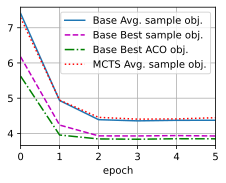

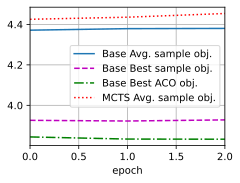

In [6]:
n_node, n_ants = 20, 20
k_sparse = 10
steps_per_epoch = 128
epochs = 5

# 阶段A：Baseline（训练阶段不启用MCTS；验证同时输出 base vs mcts 两套指标）
net = train(
    n_node,
    k_sparse,
    n_ants,
    steps_per_epoch,
    epochs,
    use_mcts=False,
    mcts_simulations=5,
    dual_eval=True,
)

# 阶段B：末期蒸馏微调（MCTS→Net hard-label CE）
# - n_ants_teacher=1：蒸馏不需要很多蚂蚁，显著提速
# - teacher_every=2：每隔一步才调用 MCTS，进一步提速
ft_optimizer = torch.optim.Adam(net.parameters(), lr=lr * 0.3)
_ = distill_finetune(
    n_node=n_node,
    k_sparse=k_sparse,
    net=net,
    optimizer=ft_optimizer,
    steps_per_epoch=64,
    epochs=2,
    n_ants_teacher=1,
    mcts_simulations=20,
    teacher_every=2,
    val_mcts_simulations=5,
)

Learn heuristic for TSP100: 

total training duration: 59.89045000076294
epoch -1: (21.377930393218993, 19.54834077835083, 18.81059883117676)
epoch 0: (11.399960069656371, 10.481556339263916, 9.709962825775147)
epoch 1: (10.019611587524414, 9.187508735656738, 8.757297139167786)
epoch 2: (9.788645973205567, 9.039171442985534, 8.59729706287384)
epoch 3: (9.729298210144043, 8.997775611877442, 8.618650074005126)
epoch 4: (9.710018243789673, 9.023997449874878, 8.635419101715089)


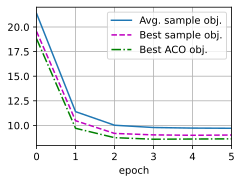

In [ ]:
n_node = 100
n_ants = 20
k_sparse = 20
steps_per_epoch = 128
epochs = 5
train(n_node, k_sparse, n_ants, steps_per_epoch, epochs, use_mcts=True, mcts_simulations=50)

Learn heuristic for TSP500: 

total training duration: 244.93165111541748
epoch -1: (69.20134498596191, 65.89540096282958, 64.83750080108642)
epoch 0: (32.194124908447264, 29.789346141815187, 26.970071601867676)
epoch 1: (22.91804630279541, 21.35917818069458, 20.387555179595946)
epoch 2: (22.124375038146972, 20.94855432510376, 19.854521675109865)
epoch 3: (21.925237503051758, 20.71975757598877, 19.70897176742554)
epoch 4: (21.793745231628417, 20.77731128692627, 19.743974590301512)


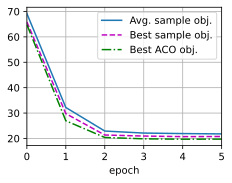

In [ ]:
n_node = 500
n_ants = 50
k_sparse = 50
steps_per_epoch = 128
epochs = 5
train(n_node, k_sparse, n_ants, steps_per_epoch, epochs, use_mcts=True, mcts_simulations=50)